In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit


df = pd.read_csv("vendor_augmented_large.csv", parse_dates=["Date"])



In [3]:
# Choose one scenario and one region (US is a good default)
use = df[df["scenario_id"] == 0].copy()
A = use["Apple_US"].values
S = use["Samsung_US"].values
t = np.arange(len(use))  # daily index
H = use["Huawei_US"].values
H_n = H / np.max(H)

In [4]:
#  (Optional) Normalize for stability
A0, S0 = A[0], S[0]
A_n = A / np.max(A)
S_n = S / np.max(S)

In [15]:
# Lotka–Volterra system
def lv(y, t, a, b, c, d):
    A, S = y
    dA = a*A - b*A*S
    dS = -c*S + d*A*S
    return [dA, dS]

def simulate(t, a, b, c, d, A0, S0):
    y0 = [A0, S0]
    sol = odeint(lv, y0, t, args=(a,b,c,d))
    return sol[:,0], sol[:,1]

# Initial conditions from normalized series
A_init = A_n[0]
S_init = S_n[0]

def fit_func(t, a, b, c, d):
    A_pred, S_pred = simulate(t, a, b, c, d, A_init, S_init)
    return np.concatenate([A_pred, S_pred])

ydata = np.concatenate([A_n, S_n])

# Use the same t (not tiled) and pass ydata accordingly
params, _ = curve_fit(
    lambda t, a, b, c, d: np.concatenate(simulate(t, a, b, c, d, A_init, S_init)),
    t,
    ydata,
    p0=[0.05, 0.01, 0.05, 0.01],
    maxfev=20000
)

A_pred, S_pred = simulate(t, *params, A_init, S_init)

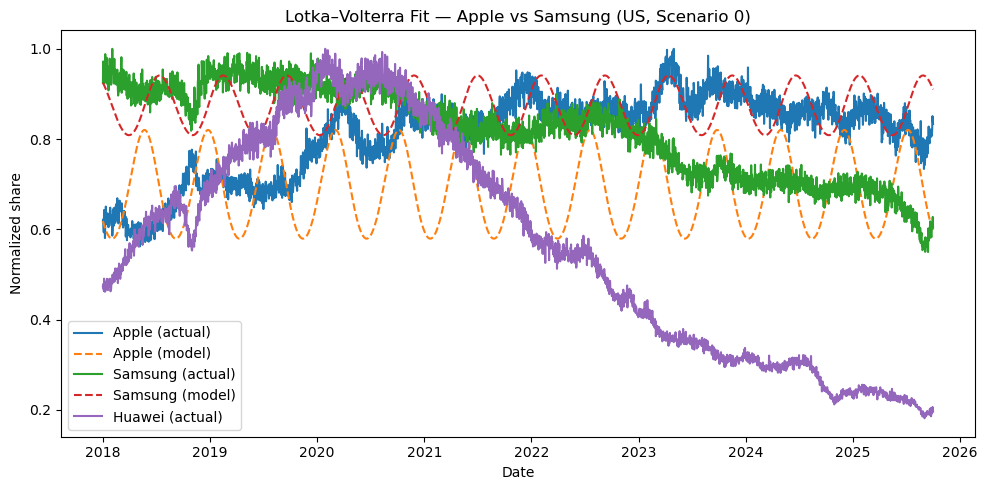

In [16]:
#  Plot actual vs model
plt.figure(figsize=(10,5))
plt.plot(use["Date"], A_n, label="Apple (actual)")
plt.plot(use["Date"], A_pred, "--", label="Apple (model)")
plt.plot(use["Date"], S_n, label="Samsung (actual)")
plt.plot(use["Date"], S_pred, "--", label="Samsung (model)")
plt.title("Lotka–Volterra Fit — Apple vs Samsung (US, Scenario 0)")
plt.xlabel("Date"); plt.ylabel("Normalized share")
plt.plot(use["Date"], H_n, label="Huawei (actual)")
plt.legend(); plt.tight_layout(); plt.show()

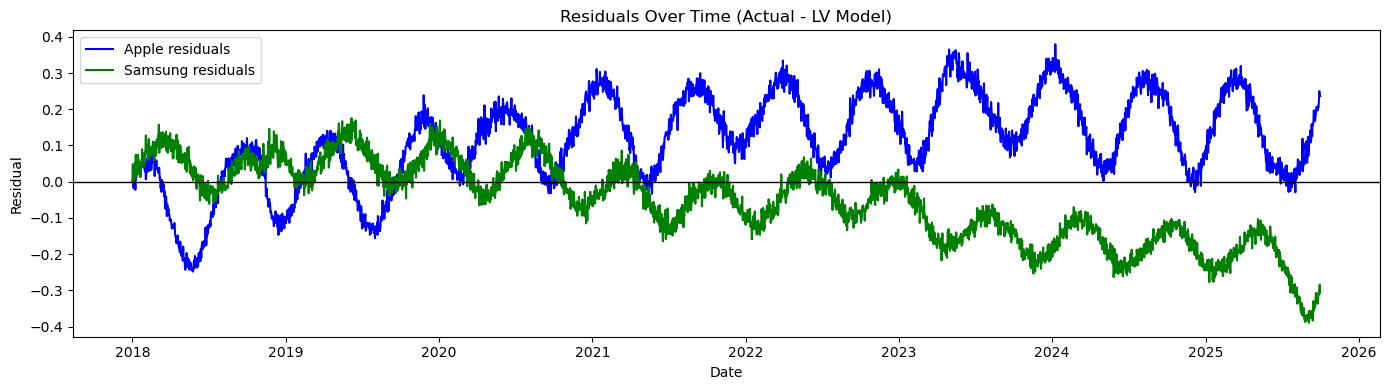

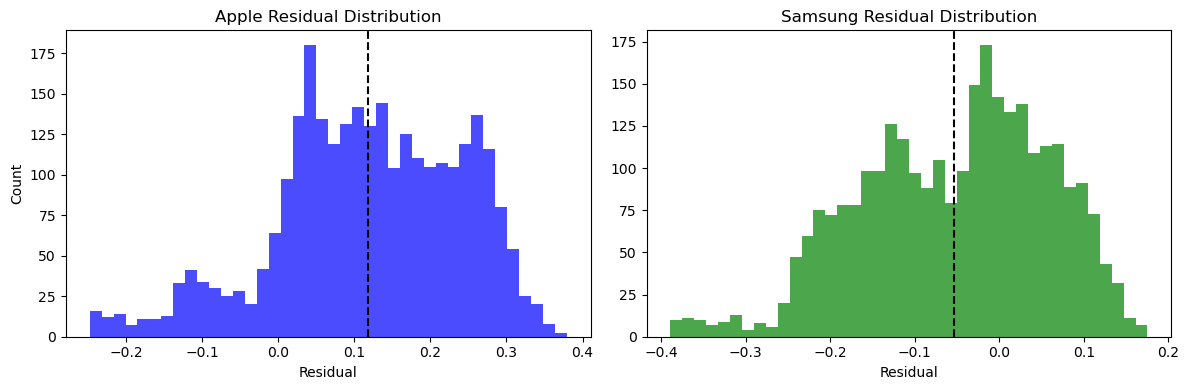

In [17]:
# --------------------------------------------------
# Residuals for normalized LV model
# --------------------------------------------------

# Compute residuals
res_A = A_n - A_pred
res_S = S_n - S_pred

# ---- Time-series residual plot ----
plt.figure(figsize=(14, 4))
plt.plot(use["Date"], res_A, label="Apple residuals", color="blue")
plt.plot(use["Date"], res_S, label="Samsung residuals", color="green")
plt.axhline(0, color="black", linewidth=1)
plt.title("Residuals Over Time (Actual - LV Model)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Residual histograms ----
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(res_A, bins=40, color="blue", alpha=0.7)
plt.axvline(np.mean(res_A), color="black", linestyle="--")
plt.title("Apple Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(res_S, bins=40, color="green", alpha=0.7)
plt.axvline(np.mean(res_S), color="black", linestyle="--")
plt.title("Samsung Residual Distribution")
plt.xlabel("Residual")

plt.tight_layout()
plt.show()

Fitted parameters:
a = 0.0111, b = 0.0197, c = 0.0061, d = 0.0140


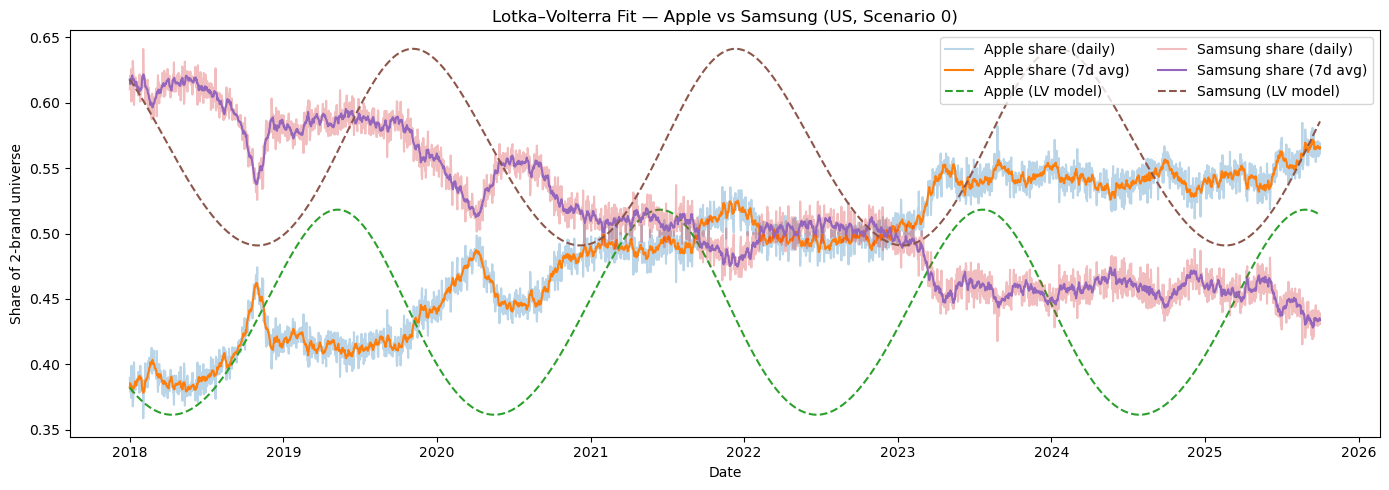

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit

# --------------------------------------------------
# 1. Select scenario and prepare data
# --------------------------------------------------

# Assume df already exists with columns:
# ["Date", "scenario_id", "Apple_US", "Samsung_US"]

use = df[df["scenario_id"] == 0].copy().reset_index(drop=True)

# Make sure Date is datetime
use["Date"] = pd.to_datetime(use["Date"])

A_raw = use["Apple_US"].astype(float).values
S_raw = use["Samsung_US"].astype(float).values
t = np.arange(len(use))  # time index in days

# --- Convert to share of 2-brand universe ---
total = A_raw + S_raw
# Avoid divide-by-zero just in case
total_safe = np.where(total == 0, np.nan, total)

A_share = A_raw / total_safe
S_share = S_raw / total_safe

# Optional: fill any NaNs created by divide-by-zero
A_share = pd.Series(A_share).ffill().bfill().values
S_share = pd.Series(S_share).ffill().bfill().values

# --- Smooth shares (7-day rolling mean) ---
A_smooth = (
    pd.Series(A_share)
    .rolling(window=7, center=True, min_periods=1)
    .mean()
    .values
)
S_smooth = (
    pd.Series(S_share)
    .rolling(window=7, center=True, min_periods=1)
    .mean()
    .values
)

# This is what we'll actually fit
A_obs = A_smooth
S_obs = S_smooth

# --------------------------------------------------
# 2. Lotka–Volterra model setup
# --------------------------------------------------

def lv(y, t, a, b, c, d):
    """
    Lotka–Volterra competition model.
    y = [A, S]
    dA/dt = a*A - b*A*S
    dS/dt = -c*S + d*A*S
    """
    A, S = y
    dA = a * A - b * A * S
    dS = -c * S + d * A * S
    return [dA, dS]

def simulate(t, a, b, c, d, A0, S0):
    """
    Integrate LV system over time t
    """
    y0 = [A0, S0]
    sol = odeint(lv, y0, t, args=(a, b, c, d))
    return sol[:, 0], sol[:, 1]

# Initial conditions from smoothed series
A0 = A_obs[0]
S0 = S_obs[0]

def lv_model_concat(t, a, b, c, d):
    """
    Curve-fit wrapper: returns [A_pred, S_pred] concatenated
    """
    A_pred, S_pred = simulate(t, a, b, c, d, A0, S0)
    return np.concatenate([A_pred, S_pred])

# Observations for curve_fit: [A_obs, S_obs] concatenated
ydata = np.concatenate([A_obs, S_obs])

# --------------------------------------------------
# 3. Parameter fitting
# --------------------------------------------------

# Initial guesses
p0 = [0.01, 0.01, 0.01, 0.01]

# Enforce non-negative parameters
params, cov = curve_fit(
    lv_model_concat,
    t,
    ydata,
    p0=p0,
    bounds=(0, np.inf),
    maxfev=50000
)

a, b, c, d = params
print("Fitted parameters:")
print(f"a = {a:.4f}, b = {b:.4f}, c = {c:.4f}, d = {d:.4f}")

# Simulate with fitted parameters
A_pred, S_pred = simulate(t, a, b, c, d, A0, S0)

# --------------------------------------------------
# 4. Plot: daily vs smoothed vs model
# --------------------------------------------------

plt.figure(figsize=(14, 5))

# Apple
plt.plot(use["Date"], A_share, alpha=0.3, label="Apple share (daily)")
plt.plot(use["Date"], A_obs,   label="Apple share (7d avg)")
plt.plot(use["Date"], A_pred,  "--", label="Apple (LV model)")

# Samsung
plt.plot(use["Date"], S_share, alpha=0.3, label="Samsung share (daily)")
plt.plot(use["Date"], S_obs,   label="Samsung share (7d avg)")
plt.plot(use["Date"], S_pred,  "--", label="Samsung (LV model)")

plt.title("Lotka–Volterra Fit — Apple vs Samsung (US, Scenario 0)")
plt.xlabel("Date")
plt.ylabel("Share of 2-brand universe")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

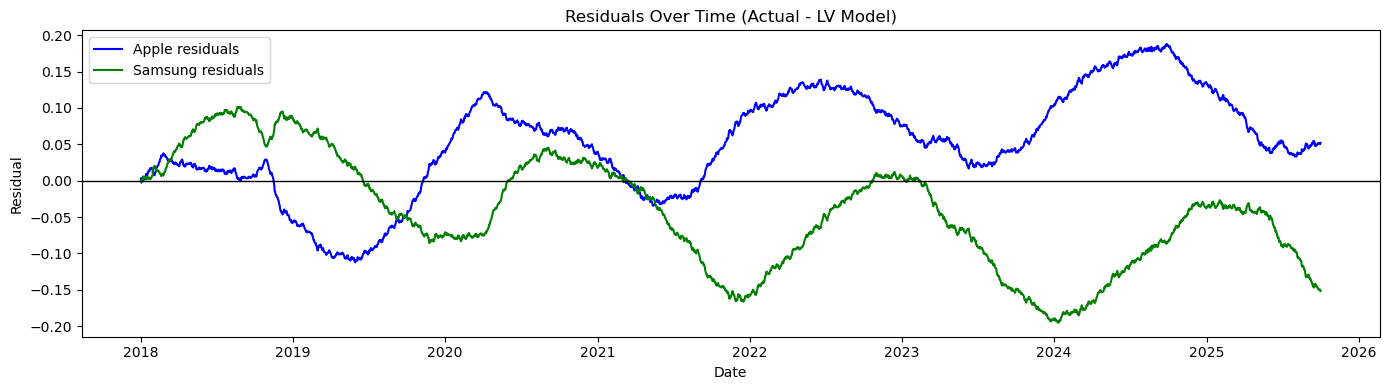

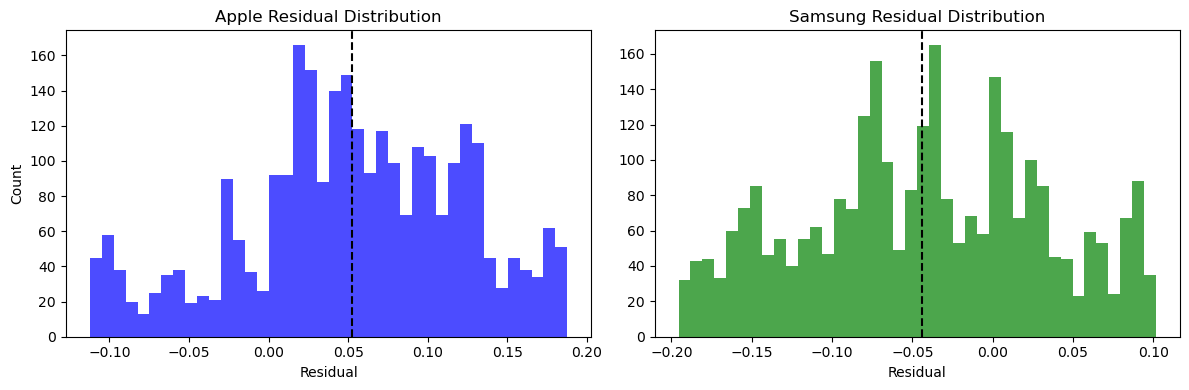

In [13]:
# --------------------------------------------------
# 5. Residual analysis
# --------------------------------------------------

# Compute residuals
res_A = A_obs - A_pred
res_S = S_obs - S_pred

# --- Time-series residuals ---
plt.figure(figsize=(14, 4))
plt.plot(use["Date"], res_A, label="Apple residuals", color="blue")
plt.plot(use["Date"], res_S, label="Samsung residuals", color="green")
plt.axhline(0, color="black", linewidth=1)
plt.title("Residuals Over Time (Actual - LV Model)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.tight_layout()
plt.show()

# --- Residual histograms ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(res_A, bins=40, color="blue", alpha=0.7)
plt.axvline(np.mean(res_A), color="black", linestyle="--")
plt.title("Apple Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(res_S, bins=40, color="green", alpha=0.7)
plt.axvline(np.mean(res_S), color="black", linestyle="--")
plt.title("Samsung Residual Distribution")
plt.xlabel("Residual")

plt.tight_layout()
plt.show()

In [7]:

eps = 0.01  # tolerance band for equilibrium

def get_regime(A_pred, S_pred, t):
    phase = np.where(
        A_pred > S_pred + eps, "Apple Dominance",
        np.where(S_pred > A_pred + eps, "Samsung Dominance", "Equilibrium")
    )
    
    segments = []
    start = 0
    for i in range(1, len(t)):
        if phase[i] != phase[start]:
            segments.append((phase[start], t[start], t[i]))
            start = i
    segments.append((phase[start], t[start], t[-1]))
    return segments

In [8]:
# === Function to run LV + return segments for a region ===
def lv_gantt_segments(df, col_A, col_B, date_col="Date", eps=0.005):
    df_region = df[[date_col, col_A, col_B]].dropna().copy()
    df_region[date_col] = pd.to_datetime(df_region[date_col])

    A = df_region[col_A].to_numpy(dtype=float)
    B = df_region[col_B].to_numpy(dtype=float)
    dates = df_region[date_col].to_numpy()

    # normalize
    A_n = (A - A.mean()) / A.std()
    B_n = (B - B.mean()) / B.std()

    t = np.arange(len(A_n), dtype=float)

    # LV system
    def lv(y, t, a, b, c, d):
        A, S = y
        return [a*A - b*A*S, -c*S + d*A*S]

    def simulate(t, a, b, c, d, A0, S0):
        sol = odeint(lv, [A0, S0], t, args=(a,b,c,d))
        return sol[:,0], sol[:,1]

    ydata = np.concatenate([A_n, B_n])
    A0, B0 = A_n[0], B_n[0]

    params, _ = curve_fit(
        lambda t_, a, b, c, d: np.concatenate(simulate(t_, a, b, c, d, A0, B0)),
        t,
        ydata,
        p0=[0.05,0.01,0.05,0.01],
        maxfev=30000
    )

    A_pred, B_pred = simulate(t, *params, A0, B0)

    # regime detection
    phase = np.where(A_pred > B_pred + eps, f"{col_A} Dominance",
            np.where(B_pred > A_pred + eps, f"{col_B} Dominance", "Equilibrium"))

    # segment building
    segments = []
    start = 0
    for i in range(1, len(phase)):
        if phase[i] != phase[start]:
            segments.append((phase[start], dates[start], dates[i-1]))
            start = i
    segments.append((phase[start], dates[start], dates[-1]))

    return segments

/var/folders/88/kpzyxpcx36d10x1br1gjq1_80000gn/T/ipykernel_8632/239730043.py:24: RuntimeWarning: invalid value encountered in scalar subtract
  dA = a*A - b*A*S
/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_minpack_py.py:1017: RuntimeWarning: overflow encountered in square
  cost = np.sum(infodict['fvec'] ** 2)
/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/var/folders/88/kpzyxpcx36d10x1br1gjq1_80000gn/T/ipykernel_8632/239730043.py:38: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(


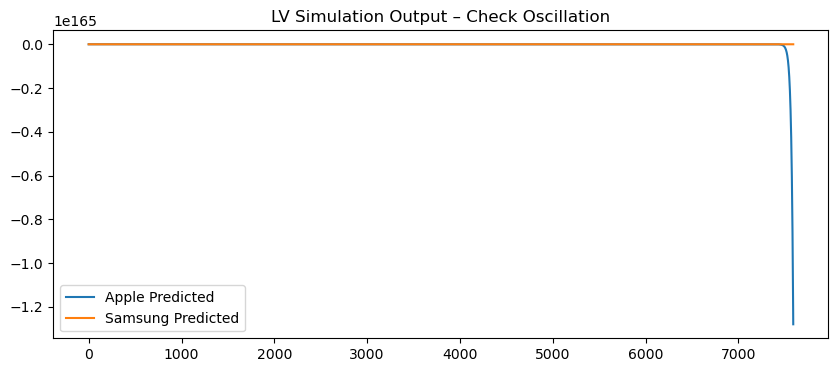

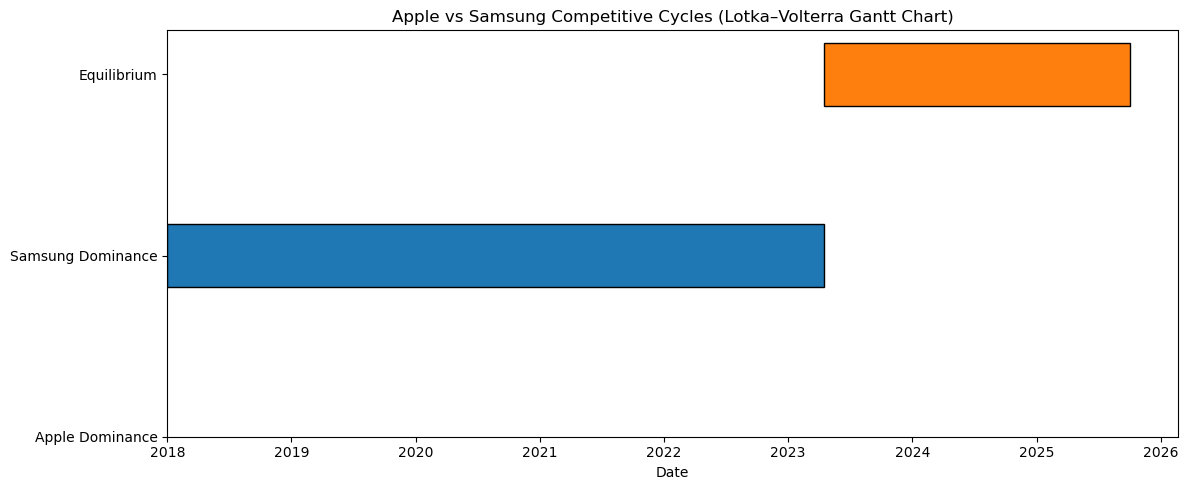

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit

# =====================
# Load and prep data
# =====================
df["Date"] = pd.to_datetime(df["Date"])  # ensure datetime format

A_n = df["Apple_US"].values  # or your normalized Apple series
S_n = df["Samsung_US"].values  # or your normalized Samsung series

# Normalize for LV
A_n = (A_n - A_n.mean()) / A_n.std()
S_n = (S_n - S_n.mean()) / S_n.std()

# =====================
# Lotka–Volterra System
# =====================
def lv(y, t, a, b, c, d):
    A, S = y
    dA = a*A - b*A*S
    dS = -c*S + d*A*S
    return [dA, dS]

def simulate(t, a, b, c, d, A0, S0):
    y0 = [A0, S0]
    sol = odeint(lv, y0, t, args=(a,b,c,d))
    return sol[:,0], sol[:,1]

t = np.arange(len(A_n))  # time index
A_init, S_init = A_n[0], S_n[0]

ydata = np.concatenate((A_n, S_n))

params, _ = curve_fit(
    lambda t, a, b, c, d: np.concatenate(simulate(t, a, b, c, d, A_init, S_init)),
    t,
    ydata,
    p0=[0.05, 0.01, 0.05, 0.01],
    maxfev=20000
)

A_pred, S_pred = simulate(t, *params, A_init, S_init)

# =====================
# Phase Detection
# =====================
eps = 0.005  # small tolerance to define equilibrium

phase = np.where(
    A_pred > S_pred + eps, "Apple Dominance",
    np.where(S_pred > A_pred + eps, "Samsung Dominance", "Equilibrium")
)

# =====================
# Extract Continuous Segments
# =====================
segments = []
start = 0
for i in range(1, len(phase)):
    if phase[i] != phase[start]:
        segments.append((phase[start], start, i))
        start = i
segments.append((phase[start], start, len(phase)-1))

# =====================
# Map to Real Dates
# =====================
dates = df["Date"].iloc[:len(A_pred)]

segments_with_dates = [
    (task, dates.iloc[start], dates.iloc[end])
    for task, start, end in segments
]

# =====================
# Plot LV to verify oscillation (optional)
# =====================
plt.figure(figsize=(10,4))
plt.plot(t, A_pred, label="Apple Predicted")
plt.plot(t, S_pred, label="Samsung Predicted")
plt.legend()
plt.title("LV Simulation Output – Check Oscillation")
plt.show()

# =====================
# Gantt Chart
# =====================
fig, ax = plt.subplots(figsize=(12,5))

tasks = ["Apple Dominance", "Samsung Dominance", "Equilibrium"]
task_y = {task: i for i, task in enumerate(tasks)}
bar_height = 0.35

for task, start_date, end_date in segments_with_dates:
    ax.barh(task_y[task],
            (end_date - start_date).days,
            left=start_date,
            height=bar_height,
            edgecolor="black")

ax.set_yticks(list(task_y.values()))
ax.set_yticklabels(tasks)
ax.set_xlabel("Date")
ax.set_title("Apple vs Samsung Competitive Cycles (Lotka–Volterra Gantt Chart)")
plt.tight_layout()
plt.show()

/var/folders/88/kpzyxpcx36d10x1br1gjq1_80000gn/T/ipykernel_8632/1914927170.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  return [a*A - b*A*S, -c*S + d*A*S]
/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_minpack_py.py:1017: RuntimeWarning: overflow encountered in square
  cost = np.sum(infodict['fvec'] ** 2)
/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/var/folders/88/kpzyxpcx36d10x1br1gjq1_80000gn/T/ipykernel_8632/1914927170.py:25: OptimizeWarning: Covariance of the parameters could not be estimated
  params,_=curve_fit(lambda t,a,b,c,d: np.concatenate(simulate(t,a,b,c,d,A[0],S[0])),


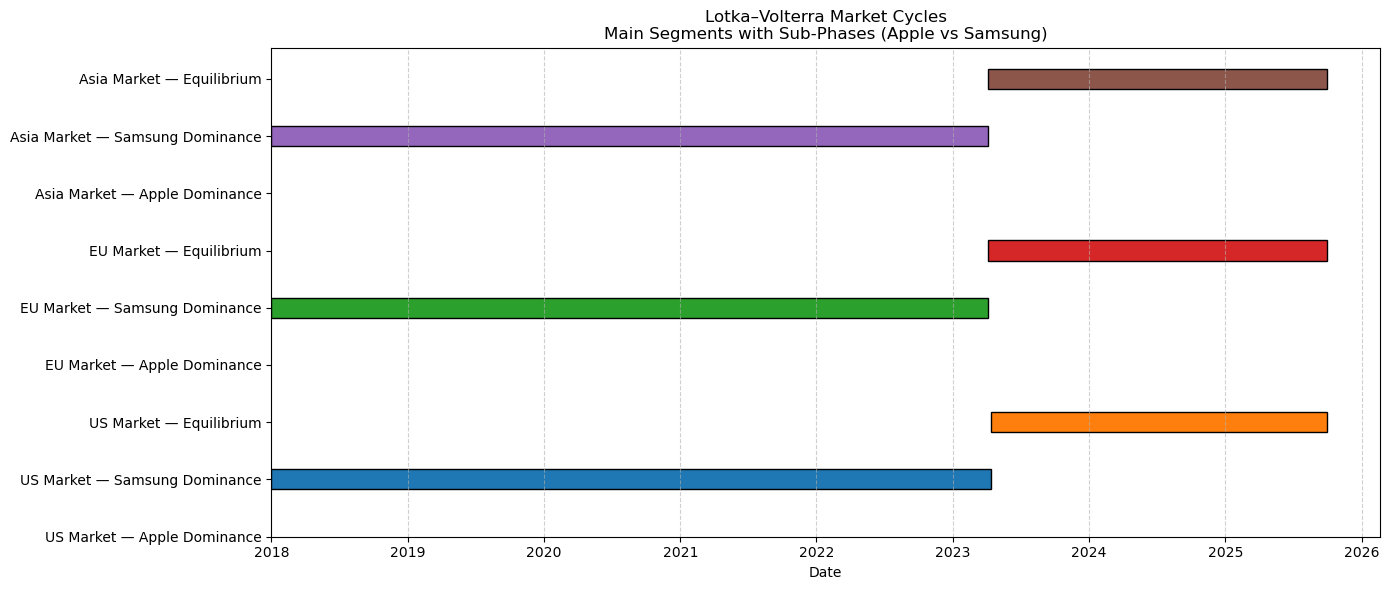

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit

# ----------------------
# LV function (unchanged)
# ----------------------
def lv(y, t, a, b, c, d):
    A, S = y
    return [a*A - b*A*S, -c*S + d*A*S]

def simulate(t, a, b, c, d, A0, S0):
    sol = odeint(lv, [A0, S0], t, args=(a,b,c,d))
    return sol[:,0], sol[:,1]

def build_segments(df, colA, colB, eps=0.005):
    A = df[colA].values
    S = df[colB].values
    A = (A - A.mean())/A.std()
    S = (S - S.mean())/S.std()

    t = np.arange(len(A))
    params,_=curve_fit(lambda t,a,b,c,d: np.concatenate(simulate(t,a,b,c,d,A[0],S[0])),
                       t, np.concatenate((A,S)),
                       p0=[0.05,0.01,0.05,0.01], maxfev=20000)

    A_pred, S_pred = simulate(t, *params, A[0], S[0])

    phase = np.where(A_pred > S_pred + eps, "Apple Dominance",
           np.where(S_pred > A_pred + eps, "Samsung Dominance", "Equilibrium"))

    segs=[]; start=0
    for i in range(1,len(phase)):
        if phase[i]!=phase[start]:
            segs.append((phase[start],start,i))
            start=i
    segs.append((phase[start],start,len(phase)-1))

    dates = df["Date"].iloc[:len(A_pred)]
    return [(p, dates.iloc[s], dates.iloc[e]) for (p,s,e) in segs]

# ----------------------
# BUILD SEGMENTS FOR US / EU / ASIA
# ----------------------
df["Date"]=pd.to_datetime(df["Date"])

US = build_segments(df, "Apple_US", "Samsung_US")
EU = build_segments(df, "Apple_EU", "Samsung_EU")
ASIA = build_segments(df, "Apple_ASIA", "Samsung_ASIA")

all_segments = []
for task, segs in [("US Market", US), ("EU Market", EU), ("Asia Market", ASIA)]:
    for (phase, s, e) in segs:
        all_segments.append((task, phase, s, e))

# ----------------------
# GANTT PLOT (Main + Sub-Rows)
# ----------------------
fig, ax = plt.subplots(figsize=(14,6))

unique_main = list(dict.fromkeys([x[0] for x in all_segments]))
unique_sub = ["Apple Dominance","Samsung Dominance","Equilibrium"]

# Row index = main + sub (multi-level rows)
row_index = {}
idx = 0
for main in unique_main:
    for sub in unique_sub:
        row_index[(main,sub)] = idx
        idx += 1

for main, phase, start, end in all_segments:
    duration = (end-start).days
    duration = max(duration,1)
    ax.barh(row_index[(main,phase)], duration, left=start,
            height=0.35, edgecolor='black')

ax.set_yticks(list(row_index.values()))
ax.set_yticklabels([f"{m} — {s}" for (m,s) in row_index.keys()])
ax.set_xlabel("Date")
ax.set_title("Lotka–Volterra Market Cycles\nMain Segments with Sub-Phases (Apple vs Samsung)")

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()